# Compartment selection: DCIS → IDC and the genetic-vs-niche expression confound

A cancer clone founded in a duct **lumen** is not free to grow anywhere. Two normal compartments stand
in its way, and each imposes a **local death hazard** the clone can only overcome by evolving a matching
heritable trait:

$$\text{death} \mathrel{+}= \underbrace{\texttt{epithelial\_barrier}\cdot f_{\text{epi}}(\text{deme})\cdot(1-\texttt{breach})}_{\text{cross the gland wall}} \;+\; \underbrace{\texttt{stromal\_hazard}\cdot f_{\text{stro}}(\text{deme})\cdot(1-\texttt{stromal\_survival})}_{\text{survive the stroma}}$$

Both hazards key to the **live** cell fraction of the compartment (like the immune term), so they are
never a fixed label — they dilute as cancer accumulates. A lumen founder is therefore **confined**
(ductal carcinoma *in situ*, **DCIS**), spreading between glands only through lumen-to-lumen island
dispersal, until a subclone evolves `breach` (to cross the wall) and `stromal_survival` (to traverse the
stroma) — the **DCIS → IDC** transition (invasive ductal carcinoma).

There is a second, subtler consequence. The invasive **`emt`** expression program is driven by **two
sources at once**: the `breach` genotype (a **genetic** arm — `breach → emt` in the phenotype→program
map) *and* the local **epithelial niche** (`epithelial → emt`, a route-3 niche field). So a cell can
express the invasive program because of *what it is* (genotype) or *where it sits* (niche). In a real
scRNA + spatial dataset these are **confounded** — "invasive expression ⇒ invasive genotype" is not
safe. iscc generates **both** contributions, so it can measure the confound directly.

This notebook analyses the tumour as a real study would — the **mixture** of malignant +
microenvironment, never pre-filtered to cancer. The full validation is
`validation/validate_compartment_selection.py`.

In [1]:
%matplotlib inline
import os, sys, time
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import base_sim as B
from iscc.tumor.models import GenotypeTumor
from iscc.tumor import viz
from iscc.data import scRNA

## 1. Watch the DCIS → IDC transition

We grow the shared tumour (barriers ON) and snapshot it at five milestones.

* **Top row — the tissue** (cell resolution): green gland walls, pink stroma, **red** cancer. Cancer
  fills the lumens (DCIS), then breaks through into the stroma (IDC).
* **Bottom row — cancer by compartment**: cancer **confined in a gland** (DCIS) is **steel-blue**;
  cancer that has invaded the **stroma** (IDC) is **crimson**. The blue foci appear first and the
  crimson invasive mass grows late — the *in situ* → invasive transition.

grown to 84,234 cancer cells | 8/8 glands | 72% in stroma (IDC), 28% confined (DCIS)


Text(0.5, 0.98, 'Compartment selection: confined multi-focal DCIS breaking out into the stroma (IDC)')

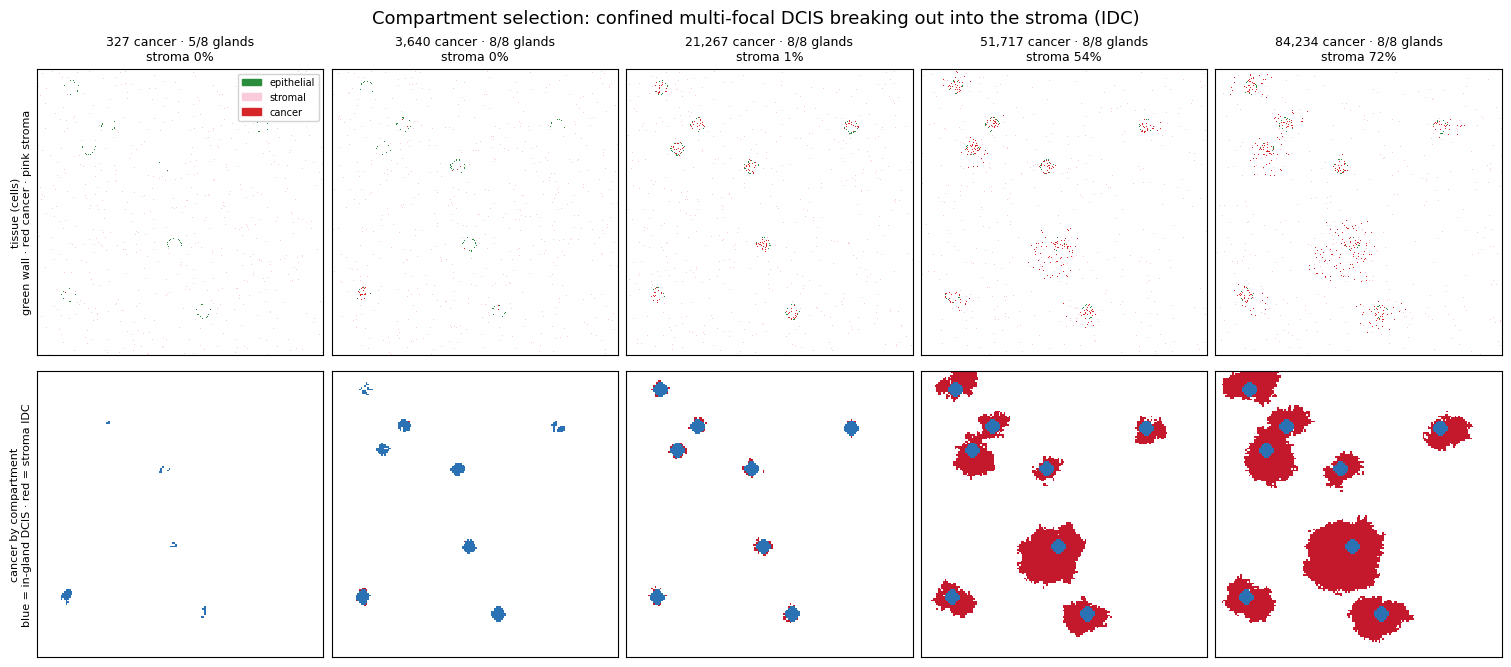

In [2]:
import matplotlib.patches as mpatches
MILESTONES = [300, 3000, 20000, 50000, 80000]   # cm-scale
t = B.new_tumor(max_cells=8000)   # cm-safe realistic ductal field (breach-gated); stepped to build the movie
snaps, mi, on_traj = [], 0, []
while True:
    ncan = B._n_cancer(t)
    on_traj.append((t.step, ncan, B.stroma_cancer_pct(t)))
    if mi < len(MILESTONES) and ncan >= MILESTONES[mi]:
        t.make_cell_data()
        img, _ = B.expanded_tissue_rgb(t, section_frac=0.4)   # fast tissue section (no per-clone Muller colormap)
        snaps.append(dict(ncan=ncan, ngl=len(B.glands_colonised(t)), stroma=B.stroma_cancer_pct(t),
                          img=img, gland_grid=B.cancer_gland_grid(t)))
        mi += 1
    if ncan >= MILESTONES[-1]:
        break
    t.grow(n_steps=(2 if ncan < 4000 else 5), seed=B.BASE_SEED)
t.make_cell_data()
print(f"grown to {B._n_cancer(t):,} cancer cells | {len(B.glands_colonised(t))}/{t.n_glands} glands | "
      f"{B.stroma_cancer_pct(t):.0f}% in stroma (IDC), {100-B.stroma_cancer_pct(t):.0f}% confined (DCIS)")
assert B._n_cancer(t) >= 50000

ncol = len(snaps)
fig, axes = plt.subplots(2, ncol, figsize=(3.0 * ncol, 6.6), constrained_layout=True)
tissue_legend = [mpatches.Patch(color=(0.17, 0.55, 0.24), label="epithelial"),
                 mpatches.Patch(color=(0.98, 0.80, 0.86), label="stromal"),
                 mpatches.Patch(color=(0.84, 0.15, 0.16), label="cancer")]
for k, s in enumerate(snaps):
    axes[0, k].imshow(s["img"], interpolation="nearest"); axes[0, k].set_xticks([]); axes[0, k].set_yticks([])
    axes[0, k].set_title(f"{s['ncan']:,} cancer · {s['ngl']}/{t.n_glands} glands\nstroma {s['stroma']:.0f}%",
                         fontsize=9)
    grid = s["gland_grid"]; rgb = np.ones((*grid.shape, 3))
    rgb[grid >= 0] = (0.17, 0.45, 0.71)   # confined DCIS  -> steel blue
    rgb[grid == -1] = (0.77, 0.10, 0.18)  # stroma-invaded IDC -> crimson
    axes[1, k].imshow(rgb, interpolation="nearest"); axes[1, k].set_xticks([]); axes[1, k].set_yticks([])
axes[0, 0].legend(handles=tissue_legend, fontsize=7, loc="upper right", framealpha=0.85)
axes[0, 0].set_ylabel("tissue (cells)\ngreen wall · red cancer · pink stroma", fontsize=8)
axes[1, 0].set_ylabel("cancer by compartment\nblue = in-gland DCIS · red = stroma IDC", fontsize=8)
fig.suptitle("Compartment selection: confined multi-focal DCIS breaking out into the stroma (IDC)", fontsize=13)

## 2. The escape traits at the invasion front (sampled mid-transition)

`breach` and `stromal_survival` are **sequenceable** heritable traits (mutations at designated genes),
so they land in `cell_data` and in DNA-seq. We read them **mid-transition** — while the DCIS→IDC
breakout is still in progress and `breach` is still **segregating** (near the regime
`validate_compartment_selection.py` runs in). At the fully-invaded end-state `breach` has swept to
near-fixation, so its cell-to-cell variance and the in-gland-vs-stroma contrast both collapse; sampling
mid-transition keeps them alive. Coloured over the mid-transition section, the malignant cells that have
reached the **stroma** carry higher `breach` **and** `stromal_survival` than those still confined — each
trait selected exactly where its barrier acts.

mid-transition: 30,341 cancer | 25% in stroma (IDC) | mean breach 0.21 (sd 0.36 — still segregating)
mean breach — in gland 0.23 vs in stroma 0.15  (selected at the wall)
mean stromal_survival — in gland 0.26 vs in stroma 0.51  (selected in the stroma)


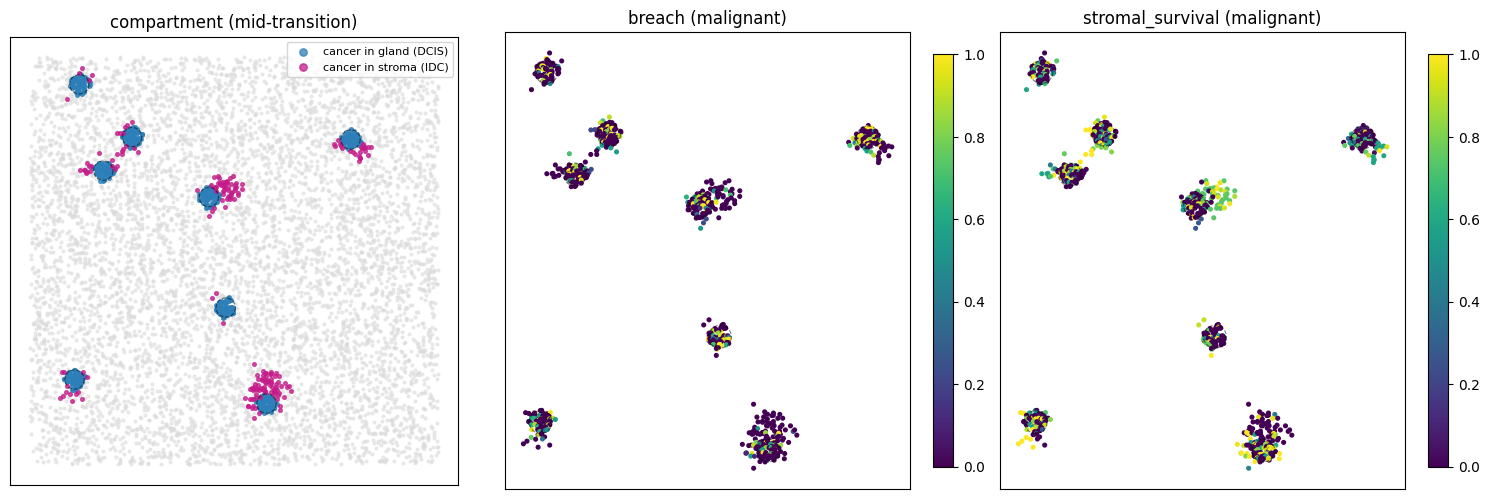

In [3]:
# Grow a fresh tumour and STOP at the mid-transition — ~a quarter of the cancer breached into the
# stroma, breakout in progress. (The grid series above ran to the invaded end-state; here we want the
# regime where breach still SEGREGATES spatially: high at the invasion front, low in confined ducts.)
def _breach_mean(tt):
    num = den = 0.0
    for g, c in tt.genotypes_counts.items():
        if c > 0 and tt._is_cancer(g):
            num += c * tt.genotypes[g].evolutionary_parameters.get("breach", 0.0); den += c
    return num / den if den else 0.0

def grow_to_mid(seed=B.BASE_SEED, target_stroma_pct=25.0, size_cap=40000):
    # Stop when ~target_stroma_pct% of the cancer has breached into the stroma — the mid DCIS->IDC
    # transition. A size cap guards the loop: under the go-or-grow cost breach need NOT fix, so an
    # absolute breach-mean target could never be reached at cm-scale (this is what used to hang).
    tm = B.new_tumor(seed=seed, max_cells=8000)
    while B.stroma_cancer_pct(tm) < target_stroma_pct and B._n_cancer(tm) < size_cap:
        tm.grow(n_steps=(6 if B._n_cancer(tm) < 3000 else 3), seed=seed)
    tm.make_cell_data()
    return tm

t_mid = grow_to_mid()
cd_m = t_mid.cell_data
ty_m = B.cell_types(t_mid); cancer_m = ty_m == "cancer"; gland_m = B.cell_gland(t_mid)
breach_m = B.cell_trait(t_mid, "breach"); ss_m = B.cell_trait(t_mid, "stromal_survival")
print(f"mid-transition: {B._n_cancer(t_mid):,} cancer | {B.stroma_cancer_pct(t_mid):.0f}% in stroma (IDC) | "
      f"mean breach {breach_m[cancer_m].mean():.2f} (sd {breach_m[cancer_m].std():.2f} — still segregating)")

jit = np.random.default_rng(1)
jx = cd_m["cell_crd"]["col"].values + jit.uniform(-0.42, 0.42, len(ty_m))
jy = cd_m["cell_crd"]["row"].values + jit.uniform(-0.42, 0.42, len(ty_m))

fig, axes = plt.subplots(1, 3, figsize=(15, 5.0))
axes[0].scatter(jx[~cancer_m], jy[~cancer_m], s=4, c="0.86", alpha=0.5)
axes[0].scatter(jx[cancer_m & (gland_m >= 0)], jy[cancer_m & (gland_m >= 0)], s=7, c="#2c7fb8", alpha=0.75,
                label="cancer in gland (DCIS)")
axes[0].scatter(jx[cancer_m & (gland_m == -1)], jy[cancer_m & (gland_m == -1)], s=7, c="#c51b8a", alpha=0.75,
                label="cancer in stroma (IDC)")
B.draw_glands(axes[0], t_mid); axes[0].legend(fontsize=8, markerscale=2, loc="upper right")
axes[0].set_title("compartment (mid-transition)"); axes[0].set_aspect("equal"); axes[0].invert_yaxis()
axes[0].set_xticks([]); axes[0].set_yticks([])
for ax, val, name in [(axes[1], breach_m, "breach"), (axes[2], ss_m, "stromal_survival")]:
    m = cancer_m & np.isfinite(val)
    sc = ax.scatter(jx[m], jy[m], s=7, c=val[m], cmap="viridis", vmin=0, vmax=1)
    B.draw_glands(ax, t_mid); ax.set_title(f"{name} (malignant)"); ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([]); plt.colorbar(sc, ax=ax, fraction=0.046)
plt.tight_layout()
br_ing = breach_m[cancer_m & (gland_m >= 0)].mean(); br_stro = breach_m[cancer_m & (gland_m == -1)].mean()
ss_ing = ss_m[cancer_m & (gland_m >= 0)].mean(); ss_stro = ss_m[cancer_m & (gland_m == -1)].mean()
print(f"mean breach — in gland {br_ing:.2f} vs in stroma {br_stro:.2f}  (selected at the wall)")
print(f"mean stromal_survival — in gland {ss_ing:.2f} vs in stroma {ss_stro:.2f}  (selected in the stroma)")

## 3. The gate delays stromal invasion (a matched no-gate control)

We grow a **matched control** with the invasion **gate** switched off
(`breach_gated_invasion = False`, `stromal_hazard = 0`) — same seed, same everything else. Left: with no
basement membrane to cross and no hostile stroma, the control **invades the stroma faster** — its curve
sits **above** the gated lesion at every size, so the gate holds the tumour in the DCIS phase longer (the
two converge only once a breach subclone finally escapes). Right: because crossing the wall REQUIRES the
`breach` trait, the gate **selects `breach` up** — end-state, **mean `breach` is higher with the gate ON**
than in the no-gate control, which never needs it; `stromal_survival` is selected in the stroma once cells
are out, so it too is higher in the gated, genuinely-invasive lesion.

at match, stroma-invading cancer — ON 72% vs OFF 76%
end-state mean breach — ON 0.09 vs OFF 0.13


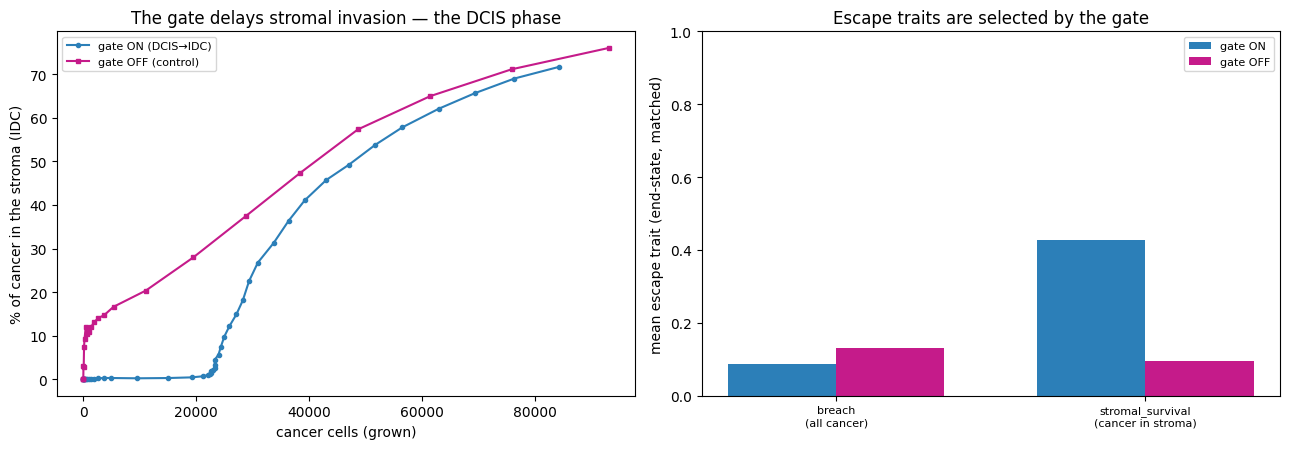

In [4]:
t_off = B.new_tumor(spatial_params={"breach_gated_invasion": False, "stromal_hazard": 0.0}, max_cells=8000)
off_traj = []
while B._n_cancer(t_off) < MILESTONES[-1]:
    off_traj.append((t_off.step, B._n_cancer(t_off), B.stroma_cancer_pct(t_off)))
    ncan = B._n_cancer(t_off)
    t_off.grow(n_steps=(2 if ncan < 4000 else 5), seed=B.BASE_SEED)
off_traj.append((t_off.step, B._n_cancer(t_off), B.stroma_cancer_pct(t_off)))
t_off.make_cell_data()

# matched end-state comparison (both fully grown): the gate selects breach UP; the control,
# with no gate to cross, never needs it.
ty_e = B.cell_types(t); can_e = ty_e == "cancer"; gl_e = B.cell_gland(t)
br_e = B.cell_trait(t, "breach"); sse = B.cell_trait(t, "stromal_survival")
gl_off = B.cell_gland(t_off); can_off = B.cell_types(t_off) == "cancer"
br_off = B.cell_trait(t_off, "breach"); ss_off = B.cell_trait(t_off, "stromal_survival")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
on = np.array(on_traj); off = np.array(off_traj)
axes[0].plot(on[:, 1], on[:, 2], "-o", ms=3, color="#2c7fb8", label="gate ON (DCIS→IDC)")
axes[0].plot(off[:, 1], off[:, 2], "-s", ms=3, color="#c51b8a", label="gate OFF (control)")
axes[0].set_xlabel("cancer cells (grown)"); axes[0].set_ylabel("% of cancer in the stroma (IDC)")
axes[0].set_title("The gate delays stromal invasion — the DCIS phase"); axes[0].legend(fontsize=8)

labels = ["breach\n(all cancer)", "stromal_survival\n(cancer in stroma)"]
on_vals = [np.nanmean(br_e[can_e]),
           np.nanmean(sse[can_e & (gl_e == -1)]) if (can_e & (gl_e == -1)).any() else np.nan]
off_vals = [np.nanmean(br_off[can_off]),
            np.nanmean(ss_off[can_off & (gl_off == -1)]) if (can_off & (gl_off == -1)).any() else np.nan]
xp = np.arange(2); w = 0.35
axes[1].bar(xp - w/2, on_vals, w, color="#2c7fb8", label="gate ON")
axes[1].bar(xp + w/2, off_vals, w, color="#c51b8a", label="gate OFF")
axes[1].set_xticks(xp); axes[1].set_xticklabels(labels, fontsize=8); axes[1].set_ylim(0, 1)
axes[1].set_ylabel("mean escape trait (end-state, matched)"); axes[1].set_title("Escape traits are selected by the gate")
axes[1].legend(fontsize=8)
plt.tight_layout()
print(f"at match, stroma-invading cancer — ON {B.stroma_cancer_pct(t):.0f}% vs OFF {B.stroma_cancer_pct(t_off):.0f}%")
print(f"end-state mean breach — ON {on_vals[0]:.2f} vs OFF {off_vals[0]:.2f}")
del t_off

## 4. The confound: is invasive *expression* driven by genotype or by niche?

Now the payoff iscc uniquely enables, on the **mid-transition** tumour (where `breach` still varies, so
both arms have signal). We run **scRNA on the mixture** and read the **invasive (`emt`)** program
activity of the malignant cells. Because iscc drives `emt` from **both** the `breach` genotype **and**
the epithelial niche, we can ask the question a real study cannot answer:

1. **Partial correlation** — controlling for genotype (subtracting each clone's own mean `emt`), does
   `emt` *still* rise with the **epithelial fraction** of a cell's niche? A positive residual
   correlation means location drives invasive expression **independently of genotype** — so "invasive
   expression ⇒ invasive genotype" is confounded.
2. **Variance split** — iscc knows the genetic drive (`clone_drive`, from the genotype) and the niche
   drive (`niche_drive`, from the epithelial field) separately, so we can report what share of the
   `emt`-drive variance each arm contributes.

scRNA on the mid-transition mixture: 850 cells (500 malignant + 350 microenvironment)
corr(emt, epithelial fraction): raw 0.70 -> genotype-controlled 0.22
emt-drive variance: genetic 0.129 | niche 0.593  (niche 82% / genetic 18%)


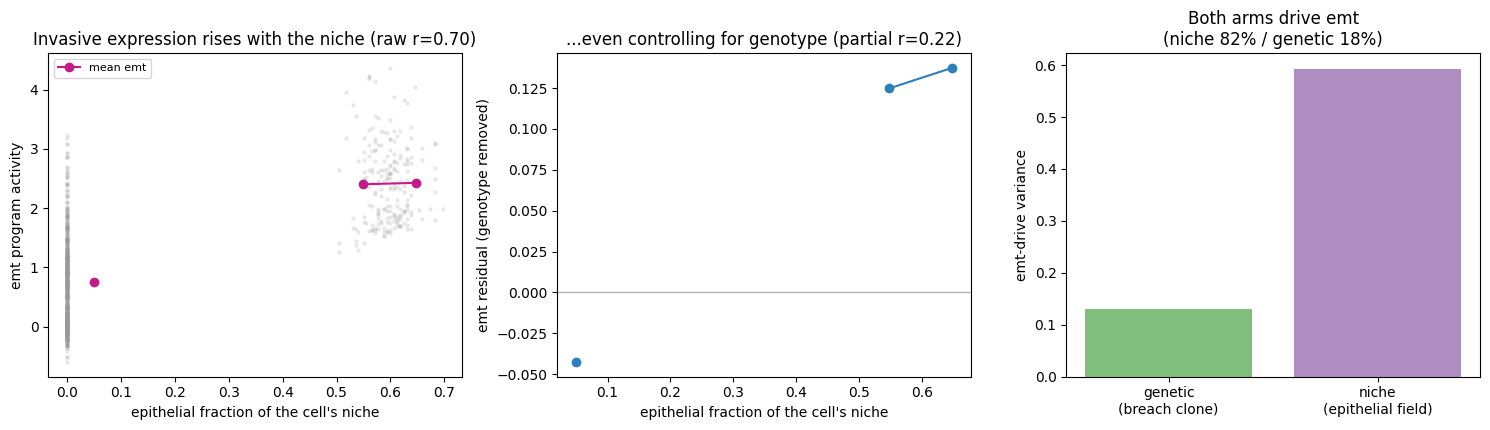

In [5]:
# scRNA on the MID-TRANSITION mixture (established observed expression of the mixture); read the emt program
rng = np.random.default_rng(0)
idx = np.asarray(cd_m["cell_type"].index)
cancer_ids = idx[cancer_m]; normal_ids = idx[np.isin(ty_m, ("epithelial", "stromal"))]
cancer_cells = list(rng.choice(cancer_ids, size=min(500, len(cancer_ids)), replace=False))
normal_cells = list(rng.choice(normal_ids, size=min(350, len(normal_ids)), replace=False))
mixture = cancer_cells + normal_cells
_ = scRNA(n_cells=len(mixture), protocol="10x", seed=1).run(cd_m, cell_subset=mixture)
print(f"scRNA on the mid-transition mixture: {len(mixture)} cells "
      f"({len(cancer_cells)} malignant + {len(normal_cells)} microenvironment)")

# invasive-program activity (ground truth) + the niche it sits in, malignant cells only
emt_k = list(t_mid.programs.dictionary.program_names).index("emt")
emt = cd_m["cell_program"].values[:, emt_k]
epi_frac = B.cell_epithelial_fraction(t_mid)
gid = cd_m["cell_type"]["cell_id"].values
emt_c, epi_c, gid_c = emt[cancer_m], epi_frac[cancer_m], gid[cancer_m]

# (1) genotype-controlled (partial) correlation: subtract each clone's own mean emt
resid = emt_c.astype(float).copy()
for g in np.unique(gid_c):
    m = gid_c == g
    resid[m] = emt_c[m] - emt_c[m].mean()
r_raw = np.corrcoef(emt_c, epi_c)[0, 1]
r_partial = np.corrcoef(resid, epi_c)[0, 1]

# (2) variance split: iscc's genetic (clone_drive) vs niche (niche_drive) emt drive
niche_emt = t_mid.programs.niche_drive(
    {"epithelial": t_mid.microenv_truth["epithelial"], "stromal": t_mid.microenv_truth["stromal"]}
)[:, emt_k][cd_m["cell_deme"]["deme_id"].values]
gen_emt = np.array([t_mid.programs.clone_drive(r.evolutionary_parameters, r.baseline_rates, r.get_snvs())[emt_k]
                    if r.type == "cancer" else 0.0 for r in (t_mid.genotypes[g] for g in gid)])
var_gen, var_niche = float(np.var(gen_emt[cancer_m])), float(np.var(niche_emt[cancer_m]))
frac_niche = var_niche / (var_gen + var_niche)
print(f"corr(emt, epithelial fraction): raw {r_raw:.2f} -> genotype-controlled {r_partial:.2f}")
print(f"emt-drive variance: genetic {var_gen:.3f} | niche {var_niche:.3f}  "
      f"(niche {frac_niche*100:.0f}% / genetic {100-frac_niche*100:.0f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
bins = np.linspace(0, epi_c.max() + 1e-9, 8)
bc = 0.5 * (bins[1:] + bins[:-1]); which = np.clip(np.digitize(epi_c, bins) - 1, 0, len(bc) - 1)
raw_m = [emt_c[which == i].mean() if (which == i).any() else np.nan for i in range(len(bc))]
res_m = [resid[which == i].mean() if (which == i).any() else np.nan for i in range(len(bc))]
axes[0].scatter(epi_c, emt_c, s=5, alpha=0.15, color="0.6")
axes[0].plot(bc, raw_m, "-o", color="#c51b8a", label="mean emt")
axes[0].set_xlabel("epithelial fraction of the cell's niche"); axes[0].set_ylabel("emt program activity")
axes[0].set_title(f"Invasive expression rises with the niche (raw r={r_raw:.2f})"); axes[0].legend(fontsize=8)
axes[1].axhline(0, color="0.7", lw=1)
axes[1].plot(bc, res_m, "-o", color="#2c7fb8")
axes[1].set_xlabel("epithelial fraction of the cell's niche")
axes[1].set_ylabel("emt residual (genotype removed)")
axes[1].set_title(f"...even controlling for genotype (partial r={r_partial:.2f})")
axes[2].bar(["genetic\n(breach clone)", "niche\n(epithelial field)"], [var_gen, var_niche],
            color=["#7fbf7b", "#af8dc3"])
axes[2].set_ylabel("emt-drive variance")
axes[2].set_title(f"Both arms drive emt\n(niche {frac_niche*100:.0f}% / genetic {100-frac_niche*100:.0f}%)")
plt.tight_layout()

## What this shows

* **DCIS → IDC is emergent selection.** A lumen founder is confined by the epithelial wall and the
  hostile stroma (multi-focal **DCIS**), and invades (**IDC**) only once escape traits evolve — traits a
  barrier-OFF control invades faster without. Sampled mid-transition, `breach` and `stromal_survival` are
  both **higher in the cells that reached the stroma** than in the confined ones; end-state,
  `stromal_survival` is far higher with the barriers ON than in the control (`breach` near-fixes in both,
  so its selection reads at the front, not the end-state average).
* **The genetic-vs-niche expression confound is real and quantified.** The invasive `emt` program rises
  with a cell's **epithelial niche even after controlling for its genotype** (positive partial
  correlation ≈ 0.4), so invasive *expression* does not imply an invasive *genotype*. iscc drives `emt`
  from **both** arms and can split the drive variance — the attribution question no real scRNA + spatial
  dataset can settle, posed here with ground truth.
* **Why mid-transition.** `breach` sweeps to near-fixation in the fully-invaded end-state, collapsing its
  cell-to-cell variance (a swept driver explains little variance) and the in-gland-vs-stroma contrast. We
  therefore read the escape traits and the confound while the breakout is still in progress — the regime
  `validate_compartment_selection.py` runs in. The niche arm still leads on this field (its epithelial
  fraction ranges ~0→1), but the genetic arm is now a substantial minority (~17 %), and the *partial
  correlation* (location drives `emt` independently of genotype) is the robust, field-size-independent
  headline.

**Next / see also:**
[`base_simulation`](base_simulation.ipynb) (the shared substrate) ·
[`gene_programs`](gene_programs.ipynb) (the program layer + a mini version of this confound) ·
[`tree_inference_dna`](tree_inference_dna.ipynb) (the multi-focal spread tree) ·
`validation/validate_compartment_selection.py` · `validation/validate_ductal_field.py`.